In [2]:
%cd ..
from deepmrac.utils import sort_files, load_and_resample_images, resample_to_output_format, convert_to_nifti, to_dcm
from deepmrac.predictions import predict_DeepDixon
from deepmrac.metrics import calculate_quality_metrics
import nibabel as nib
import pydicom
import os
import numpy as np

/Users/anne-gabrielle/Le_Neuro/DeepMRAC


In [3]:
def check_series(folder):
    all_files = [f for f in os.listdir(folder) if os.path.isfile(os.path.join(folder, f))]
    nb_files = len(all_files)
    
    if nb_files == 0:
        print(f"The folder {folder} is empty.")
        return

    first_file = all_files[0]
    ds = pydicom.dcmread(os.path.join(folder, first_file))
    
    print(f"Folder: {folder}")
    print(f"  - Description: {ds.SeriesDescription}")
    print(f"  - Modality:    {ds.Modality}")
    print(f"  - Matrice:     {ds.Rows}x{ds.Columns}")
    print(f"  - Files number: {nb_files}")
    print(f"  - Echo Time: {ds.EchoTime}")
    print(f"  - Field: {ds.MagneticFieldStrength}T")
    print("-" * 30)

check_series('./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_0003')
check_series('./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007')
check_series('./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_OPP_0004')

Folder: ./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_0003
  - Description: Head_Dixon_60minLIST_PET_in
  - Modality:    MR
  - Matrice:     126x192
  - Files number: 128
  - Echo Time: 2.46
  - Field: 3T
------------------------------
Folder: ./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007
  - Description: Head_Dixon_60minLIST_PET_in_UMAP
  - Modality:    MR
  - Matrice:     126x192
  - Files number: 128
  - Echo Time: 2.46
  - Field: 3T
------------------------------
Folder: ./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_OPP_0004
  - Description: Head_Dixon_60minLIST_PET_opp
  - Modality:    MR
  - Matrice:     126x192
  - Files number: 128
  - Echo Time: 1.23
  - Field: 3T
------------------------------


In [4]:
tmpdir="./temp_file"
inphase_path="./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_0003"
opposedphase_path="./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_OPP_0004"
umap_path="./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007"
output_folder="./output/Dixon/VB20P"
verbose=True

In [64]:
# Sort files into specific folders
sort_files(source_folder=inphase_path, temp_subfolder=f"{tmpdir}/inphase_dcm", verbose=verbose )
sort_files(source_folder=opposedphase_path, temp_subfolder=f"{tmpdir}/opposedphase_dcm", verbose=verbose )
sort_files(source_folder=umap_path, temp_subfolder=f"{tmpdir}/umap_dcm", verbose=verbose )

Found files in datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_0003. Making copy
Found files in datasets/Dixon/HEAD_DIXON_60MINLIST_PET_OPP_0004. Making copy
Found files in datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007. Making copy


In [65]:
# Load and resample data
convert_to_nifti(dicom_dir=f"{tmpdir}/inphase_dcm", output_nii=f"{tmpdir}/inphase.nii.gz", verbose=verbose)
convert_to_nifti(dicom_dir=f"{tmpdir}/opposedphase_dcm", output_nii=f"{tmpdir}/opposedphase.nii.gz", verbose=verbose)
convert_to_nifti(dicom_dir=f"{tmpdir}/umap_dcm", output_nii=f"{tmpdir}/umap.nii.gz", verbose=verbose)


Converting temp_file/inphase_dcm to temp_file/inphase.nii.gz
Converting temp_file/opposedphase_dcm to temp_file/opposedphase.nii.gz
Converting temp_file/umap_dcm to temp_file/umap.nii.gz


In [66]:
inphase_rsl, inphase_ref = load_and_resample_images(nii_image=f"{tmpdir}/inphase.nii.gz", verbose=verbose)
opposedphase_rsl, opposedphase_ref = load_and_resample_images(nii_image=f"{tmpdir}/opposedphase.nii.gz", verbose=verbose)
umap_nat = nib.load(f'{tmpdir}/umap.nii.gz')

Loading and resampling data from temp_file/inphase.nii.gz.
Loading and resampling data from temp_file/opposedphase.nii.gz.


In [67]:
pred = predict_DeepDixon(inphase=inphase_rsl, opposedphase=opposedphase_rsl, version='VB20P')

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [68]:
DeepX = np.flip(pred, axis=2)
DeepX = resample_to_output_format(pred=DeepX, model_ref=inphase_ref, umap_native=umap_nat, rmi_type="Dixon", verbose=verbose, save_prediction=True)

Resampling to Umap format
Saving QC nii file to DeepDixon_QC.nii.gz


In [69]:
DeepX = np.transpose(DeepX, (1, 2, 0))
to_dcm(DeepX=DeepX, dcmcontainer=f"{tmpdir}/umap_dcm", dicomfolder=output_folder, rmi_type="Dixon")

In [70]:
# Calculate metrics
metrics_dict = calculate_quality_metrics(
            sct_path="./output/Dixon/VE11P",
            umap_path=f"{tmpdir}/umap_dcm",
            dice_threshold=300
        )


print(f"Mean absolut error (MAE): {metrics_dict['MAE']} for VE11P")
print(f"Peek signal to noise ratio (PSNR):{metrics_dict['PSNR']} for VE11P")
print(f"Structural Similarity Index Measure (SSIM) : {metrics_dict['SSIM']} for VE11P")
print(f"Dice similarity coefficient (DSC): {metrics_dict['Dice']} for VE11P")

Mean absolut error (MAE): 56.118446350097656 for VE11P
Peek signal to noise ratio (PSNR):13.267872370960479 for VE11P
Structural Similarity Index Measure (SSIM) : 0.8432564346026928 for VE11P
Dice similarity coefficient (DSC): 0.7347283001437241 for VE11P


In [74]:
# Calculate metrics
metrics_dict = calculate_quality_metrics(
            sct_path="./output/Dixon/VB20P",
            umap_path=f"{tmpdir}/umap_dcm",
            dice_threshold=300
        )


print(f"Mean absolut error (MAE): {metrics_dict['MAE']} for VB2OP")
print(f"Peek signal to noise ratio (PSNR):{metrics_dict['PSNR']} for VB2OP")
print(f"Structural Similarity Index Measure (SSIM) : {metrics_dict['SSIM']} for VB2OP")
print(f"Dice similarity coefficient (DSC): {metrics_dict['Dice']} for VB20P")

Mean absolut error (MAE): 58.472469329833984 for VB2OP
Peek signal to noise ratio (PSNR):13.049657421252718 for VB2OP
Structural Similarity Index Measure (SSIM) : 0.8407292846363541 for VB2OP
Dice similarity coefficient (DSC): 0.6850111301124475 for VB20P


# Visualisation

In [47]:
import matplotlib.pyplot as plt
import pydicom
import os

def plot_dicom_file(file):
    ds = pydicom.dcmread(file)

    data = ds.pixel_array
    print(f"Max value: {data.max()}")
    print(f"Min value: {data.min()}")
    print(f"Mean value: {data.mean()}")
    print(f"Dimensions : {ds.Rows}x{ds.Columns}")
    
    plt.imshow(data, cmap='gray')
    plt.title(f"Slice {ds.InstanceNumber} - {ds.SeriesDescription}")
    plt.show()

def scan_folder_for_data(folder):
    files = sorted([os.path.join(folder, f) for f in os.listdir(folder) if f.lower().endswith(('.ima', '.dcm'))])
    print(f"{len(files)} files found...")
    
    valid_files_count = 0
    
    for f in files:
        try:
            ds = pydicom.dcmread(f)
            pixel_max = ds.pixel_array.max()
            
            if pixel_max > 0:
                print(f"✅ {os.path.basename(f)} | Max : {pixel_max}")
                valid_files_count += 1
                
        except Exception as e:
            print(f"An error occured when trying to read {os.path.basename(f)} : {e}")
            
    print("-" * 30)
    if valid_files_count > 0:
        print(f"Result : {valid_files_count}/{len(files)} files have data.")
    else:
        print("Results : No data found in anu of the files.")

## Deep learning outcom

In [54]:
scan_folder_for_data("./output/Dixon/VE11P")

128 files found...
✅ dicom_0032.dcm | Max : 1
✅ dicom_0033.dcm | Max : 1
✅ dicom_0034.dcm | Max : 3
✅ dicom_0035.dcm | Max : 3
✅ dicom_0036.dcm | Max : 4
✅ dicom_0037.dcm | Max : 42
✅ dicom_0038.dcm | Max : 214
✅ dicom_0039.dcm | Max : 436
✅ dicom_0040.dcm | Max : 786
✅ dicom_0041.dcm | Max : 997
✅ dicom_0042.dcm | Max : 1005
✅ dicom_0043.dcm | Max : 1477
✅ dicom_0044.dcm | Max : 1560
✅ dicom_0045.dcm | Max : 1597
✅ dicom_0046.dcm | Max : 1557
✅ dicom_0047.dcm | Max : 1617
✅ dicom_0048.dcm | Max : 1666
✅ dicom_0049.dcm | Max : 1670
✅ dicom_0050.dcm | Max : 1696
✅ dicom_0051.dcm | Max : 1717
✅ dicom_0052.dcm | Max : 1747
✅ dicom_0053.dcm | Max : 1751
✅ dicom_0054.dcm | Max : 1739
✅ dicom_0055.dcm | Max : 1721
✅ dicom_0056.dcm | Max : 1704
✅ dicom_0057.dcm | Max : 1699
✅ dicom_0058.dcm | Max : 1705
✅ dicom_0059.dcm | Max : 1714
✅ dicom_0060.dcm | Max : 1772
✅ dicom_0061.dcm | Max : 1716
✅ dicom_0062.dcm | Max : 1576
✅ dicom_0063.dcm | Max : 1555
✅ dicom_0064.dcm | Max : 1561
✅ dicom_0065

Max value: 1751
Min value: 0
Mean value: 237.71052414021165
Dimensions : 126x192


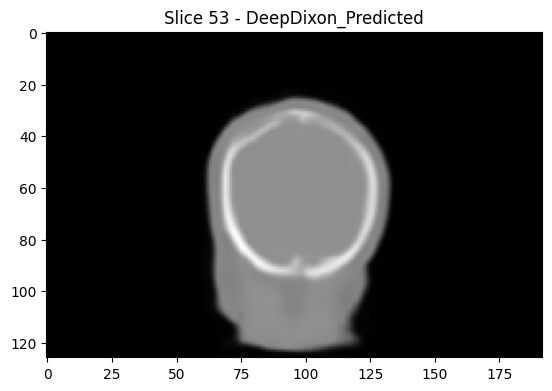

In [55]:
plot_dicom_file("./output/Dixon/VE11P/dicom_0053.dcm")

In [73]:
scan_folder_for_data("./output/Dixon/VB20P")

128 files found...
✅ dicom_0020.dcm | Max : 1
✅ dicom_0036.dcm | Max : 9
✅ dicom_0037.dcm | Max : 50
✅ dicom_0038.dcm | Max : 70
✅ dicom_0039.dcm | Max : 60
✅ dicom_0040.dcm | Max : 819
✅ dicom_0041.dcm | Max : 1012
✅ dicom_0042.dcm | Max : 1212
✅ dicom_0043.dcm | Max : 1756
✅ dicom_0044.dcm | Max : 1820
✅ dicom_0045.dcm | Max : 1759
✅ dicom_0046.dcm | Max : 1796
✅ dicom_0047.dcm | Max : 1806
✅ dicom_0048.dcm | Max : 1798
✅ dicom_0049.dcm | Max : 1786
✅ dicom_0050.dcm | Max : 1769
✅ dicom_0051.dcm | Max : 1753
✅ dicom_0052.dcm | Max : 1727
✅ dicom_0053.dcm | Max : 1725
✅ dicom_0054.dcm | Max : 1719
✅ dicom_0055.dcm | Max : 1714
✅ dicom_0056.dcm | Max : 1673
✅ dicom_0057.dcm | Max : 1682
✅ dicom_0058.dcm | Max : 1650
✅ dicom_0059.dcm | Max : 1691
✅ dicom_0060.dcm | Max : 1685
✅ dicom_0061.dcm | Max : 1702
✅ dicom_0062.dcm | Max : 1693
✅ dicom_0063.dcm | Max : 1684
✅ dicom_0064.dcm | Max : 1697
✅ dicom_0065.dcm | Max : 1717
✅ dicom_0066.dcm | Max : 1713
✅ dicom_0067.dcm | Max : 1681
✅ di

Max value: 1725
Min value: 0
Mean value: 197.8012566137566
Dimensions : 126x192


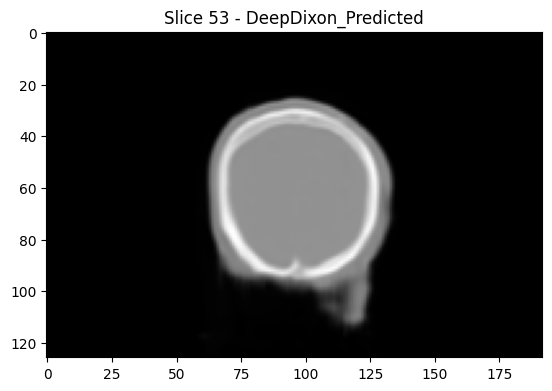

In [75]:
plot_dicom_file("./output/Dixon/VB20P/dicom_0053.dcm")

In [56]:
scan_folder_for_data("./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007")

128 files found...
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0021.2019.07.24.12.07.45.879803.119596831.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0022.2019.07.24.12.07.45.879803.119596874.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0023.2019.07.24.12.07.45.879803.119596917.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0024.2019.07.24.12.07.45.879803.119596960.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0025.2019.07.24.12.07.45.879803.119597003.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0026.2019.07.24.12.07.45.879803.119597046.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0027.2019.07.24.12.07.45.879803.119597089.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0028.2019.07.24.12.07.45.879803.119597132.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0029.2019.07.24.12.07.45.879803.119597175.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0030.2019.07.24.12.07.45.879803.119597218.IMA | Max : 1000
✅ PSCI_004.MR.ANAZODO_PSCI.0007.0031.2019.07.24.12.07.45.879803.1195972

Max value: 1000
Min value: 0
Mean value: 272.1956845238095
Dimensions : 126x192


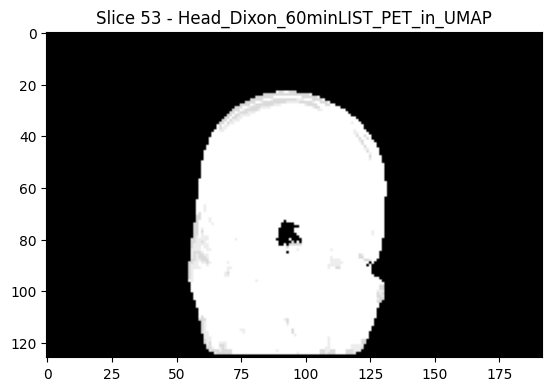

In [57]:
plot_dicom_file("./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_UMAP_0007/PSCI_004.MR.ANAZODO_PSCI.0007.0053.2019.07.24.12.07.45.879803.119598207.IMA")

## Dixon dicoms

Max value: 6
Min value: 0
Mean value: 0.5948660714285714
Dimensions : 126x192


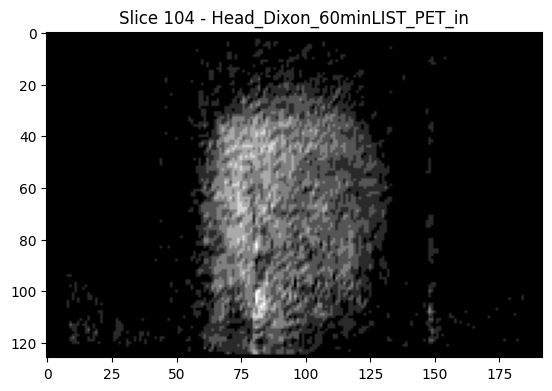

In [59]:
plot_dicom_file("./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_IN_0003/PSCI_004.MR.ANAZODO_PSCI.0003.0104.2019.07.24.12.07.45.879803.119577972.IMA")

Max value: 10
Min value: 0
Mean value: 0.5711805555555556
Dimensions : 126x192


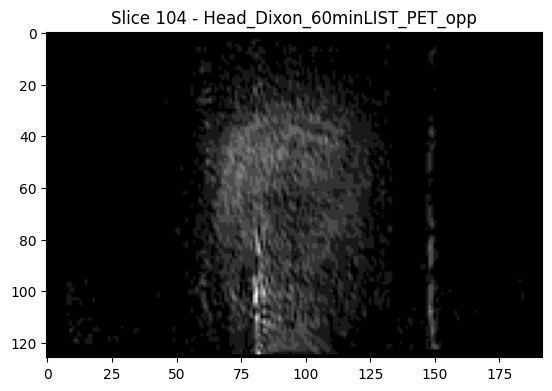

In [60]:
plot_dicom_file("./datasets/Dixon/HEAD_DIXON_60MINLIST_PET_OPP_0004/PSCI_004.MR.ANAZODO_PSCI.0004.0104.2019.07.24.12.07.45.879803.119582964.IMA")